<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 4</b></center>    
<pre>    

## Simple Linear Regression

## Step 1. Import the necessary libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2. Import the dataset

In [24]:
df = pd.read_csv('50_Startups.csv')

In [25]:
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


## Step 3 . Check the State Column

In [26]:
df['State'].value_counts()


State
New York      17
California    17
Florida       16
Name: count, dtype: int64

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

## Step 4 . Splitting dataset in to input and output

In [27]:
from sklearn.model_selection import train_test_split

X = df.drop(['Profit'], axis=1)
y = df['Profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:

X_train

,R&D Spend,Administration,Marketing Spend,State
12,93863.75,127320.38,249839.44,Florida
4,142107.34,91391.77,366168.42,Florida
37,44069.95,51283.14,197029.42,California
8,120542.52,148718.95,311613.29,New York
3,144372.41,118671.85,383199.62,New York
6,134615.46,147198.87,127716.82,California
41,27892.92,84710.77,164470.71,Florida
46,1315.46,115816.21,297114.46,Florida
47,0.00,135426.92,0.00,California
15,114523.61,122616.84,261776.23,New York


## Step 5 . Convert state Column into Numeric Column

## Step 5.1 .  Perform Transformation

In [29]:
X_train = pd.get_dummies(X_train, columns=['State'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['State'], drop_first=True)

In [30]:
X_train

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
12,93863.75,127320.38,249839.44,True,False
4,142107.34,91391.77,366168.42,True,False
37,44069.95,51283.14,197029.42,False,False
8,120542.52,148718.95,311613.29,False,True
3,144372.41,118671.85,383199.62,False,True
6,134615.46,147198.87,127716.82,False,False
41,27892.92,84710.77,164470.71,True,False
46,1315.46,115816.21,297114.46,True,False
47,0.00,135426.92,0.00,False,False
15,114523.61,122616.84,261776.23,False,True


## Step 6 . Dummy variable trap

In [31]:
# Already Performed using | drop_first =True
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

## Step 7 Splitting dataset in to Train and Test

## Step 8  Import LinearRegression model from linear_model family 

In [32]:
from sklearn.linear_model import LinearRegression

## Step 9  Fit the data

In [33]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Step 10  Predict the data

In [34]:
y_pred = model.predict(X_test)

## Step 11  Display Result

In [37]:
# y_test and y_predict
comparison = pd.DataFrame({
    "Actual Profit": y_test,
    "Predicted Profit": y_pred
})

comparison.head()

,Actual Profit,Predicted Profit
13,134307.35,126362.879083
39,81005.76,84608.453836
30,99937.59,99677.494251
45,64926.08,46357.460686
17,125370.37,128750.482885


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1351: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


<Axes: xlabel='Actual Profit', ylabel='Predicted Profit'>

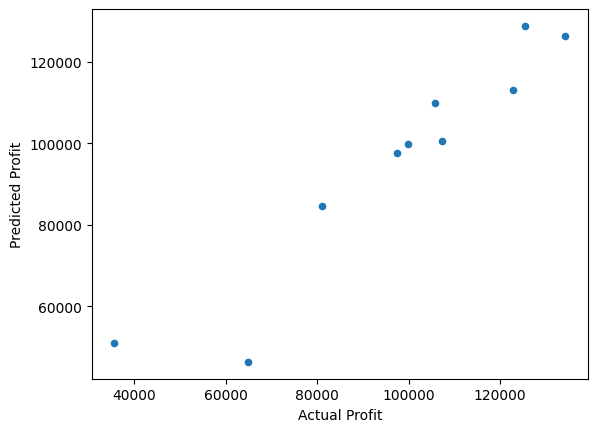

In [ ]:
comparison.plot(kind='scatter', x='Actual Profit', y='Predicted Profit')

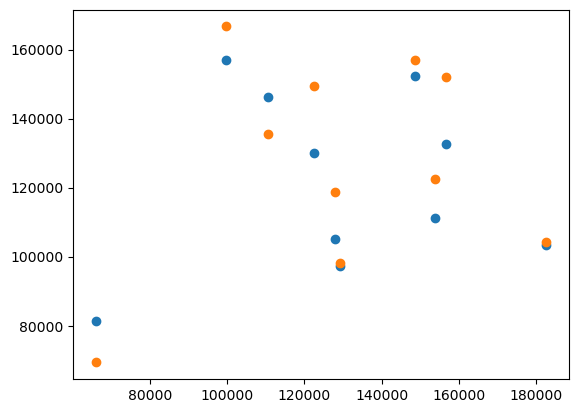

## RSS

1458292921.1634684

10

1458292921.1634684

10

## R Square

0.7533298848190992